# Etape 5 Entrainement

But : entraîner plusieurs modèles (régression logistique, arbre de décision, Random Forest).

Approche : comparer leurs performances avec des métriques adaptées au churn (accuracy, precision, recall, F1, AUC).

Particularité churn → dataset déséquilibré, donc précision seule ne suffit pas.

### Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


### Charger les jeux prétraités :

In [3]:
train_df = pd.read_parquet("../data/models/train.parquet")
test_df  = pd.read_parquet("../data/models/test.parquet")

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]


## Régression Logistique

Justification : modèle de base, interprétable, souvent efficace pour le churn.

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]


Évaluation :

In [5]:
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_proba_lr))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

AUC: 0.8419179002299206


Courbe ROC :

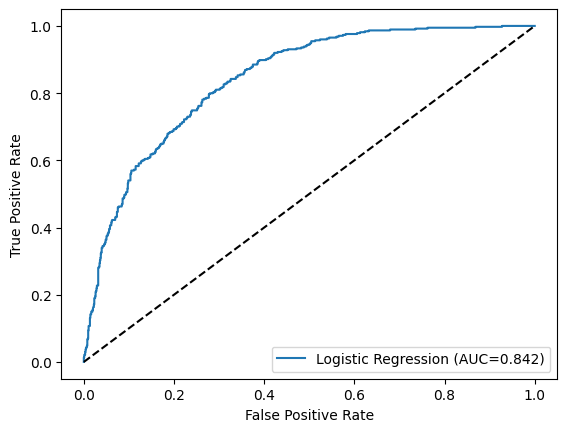

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, label="Logistic Regression (AUC=%.3f)" % roc_auc_score(y_test, y_proba_lr))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


## Arbre de Décision

Justification : modèle plus flexible, permet de voir les règles de décision.

In [7]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, y_proba_dt))


              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8302862383425044


Feature importance :

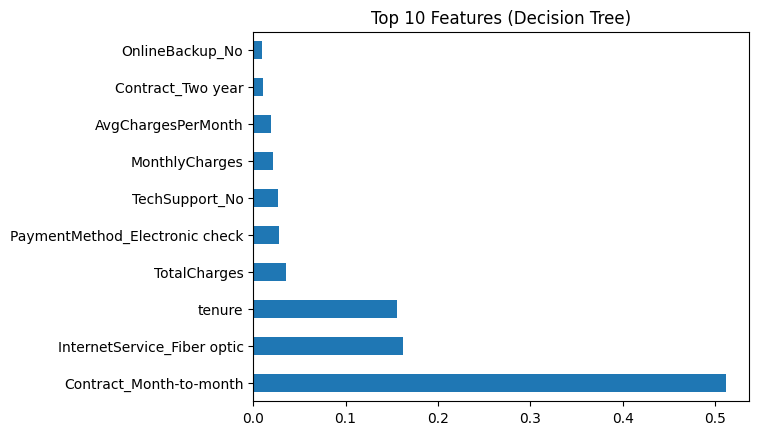

In [8]:
feat_importances = pd.Series(dt.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Features (Decision Tree)")
plt.show()


## Random Forest

Justification : ensemble de plusieurs arbres → robuste, meilleure performance.

In [9]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8401624945103207


Feature importance :

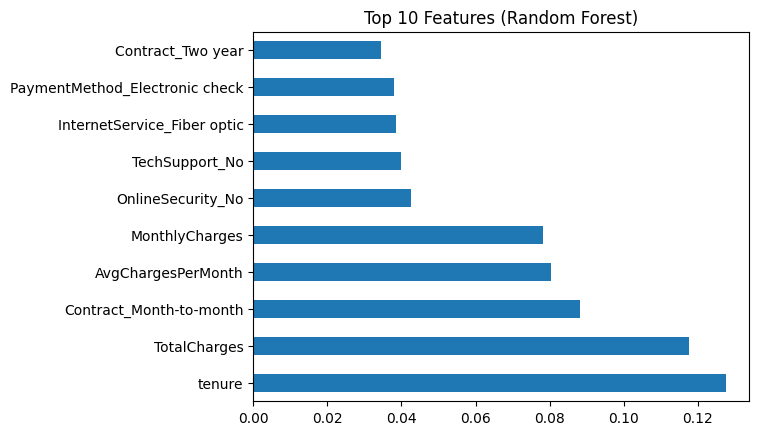

In [10]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Features (Random Forest)")
plt.show()


## Comparaison des modèles

Tableau récapitulatif : précision, recall, F1, AUC.

In [11]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        (y_pred_lr == y_test).mean(),
        (y_pred_dt == y_test).mean(),
        (y_pred_rf == y_test).mean()
    ],
    "AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

print(results)


                 Model  Accuracy       AUC
0  Logistic Regression  0.806246  0.841918
1        Decision Tree  0.798439  0.830286
2        Random Forest  0.796309  0.840162


## Sauvegarde des modèles

Pour les réutiliser plus tard (dashboard ou API).

In [15]:
os.makedirs("../models", exist_ok=True)
joblib.dump(log_reg, "../models/log_reg.pkl")
joblib.dump(dt, "../models/decision_tree.pkl")
joblib.dump(rf, "../models/random_forest.pkl")


['../models/random_forest.pkl']

## Conclusion intermédiaire

Quel modèle est le meilleur selon AUC / Recall ?

Régression logistique : baseline, souvent bon rappel.

Random Forest : en général le meilleur compromis.

Décision tree : utile pour interprétation.